# Run pipeline and compare models across five elections
Run all cells to refresh the data, evaluate all eight candidates on 2005, 2010, 2015, 2017 and 2019, and select by mean election accuracy. Each forecast uses only earlier elections for tuning and fitting. The selected procedure is then retuned and fitted using history through 2019 for the 2024 retrospective benchmark.

This run includes many inner fits and neural ensembles and can take substantially longer than the previous single-election comparison. Progress is printed during selection. The notebook has not been executed as part of this refactor.

`train.csv` and `test.csv` remain in `notebooks/outputs/`. The same output directory receives `model_accuracies.csv` (five-election summary), `model_accuracies_elections.csv`, `model_accuracies_predictions.csv`, and `model_accuracies_report.json` (search settings, fit records, seeds, durations, versions and completion status). Reruns overwrite these files; check the report status before using saved results.


In [1]:
from election import paths
from election.pipeline.run_pipeline import run_pipeline

project_root = paths.project_root()

output_directory = project_root / "notebooks" / "outputs"
print(f"Saving pipeline outputs to: {output_directory}")


Running pipeline from: /workspaces/Election-Prediction-12.08/src/election/pipeline/run_pipeline.py
Saving model accuracies to: /workspaces/Election-Prediction-12.08/analysis/notebooks


In [2]:
selection = run_pipeline(output_dir=output_directory)
final_model = selection.model
report = selection.report
model_type = selection.model_name

print("\nFive-election candidate comparison (equal election weights):")
display(report.scorecard())
print("\nIndividual outer-election scores:")
import pandas as pd
display(pd.DataFrame(report.outer_results)[[
    "candidate", "election", "accuracy", "changed_seat_accuracy",
    "changed_seat_evaluation_rows", "retained_seat_accuracy", "log_loss",
    "previous_winner_accuracy", "runtime_seconds"
]])
print(f"Selected model: {model_type}")
print(f"Report status: {report.status}")
print("Final fitted settings:", final_model.hyperparameters)
print("Final fit record:", report.final_fit)


/workspaces/Election-Prediction-12.08/.venv/lib/python3.14/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


Outer election 2005: tuning and fitting XGBoost
Outer election 2005: tuning and fitting Random Forest
Outer election 2005: tuning and fitting Logistic Regression
Outer election 2005: tuning and fitting NN01: 32/16 validation-selected rate
  NN01: 32/16 validation-selected rate: 1/4 configurations scored
  NN01: 32/16 validation-selected rate: 4/4 configurations scored
Outer election 2005: tuning and fitting NN02: 64/32 validation-selected rate
  NN02: 64/32 validation-selected rate: 1/8 configurations scored
  NN02: 64/32 validation-selected rate: 2/8 configurations scored
  NN02: 64/32 validation-selected rate: 4/8 configurations scored
  NN02: 64/32 validation-selected rate: 7/8 configurations scored
Outer election 2005: tuning and fitting NN03: 16 units fixed rate 0.3
Outer election 2005: tuning and fitting XGBoost Expanded
Outer election 2005: tuning and fitting Conditional XGBoost
Outer election 2010: tuning and fitting XGBoost
Outer election 2010: tuning and fitting Random Forest

,candidate,mean_accuracy,worst_accuracy,best_accuracy,accuracy_range,latest_three_accuracy,runtime_seconds,mean_changed_seat_accuracy,changed_seat_accuracy_elections,mean_retained_seat_accuracy,...,previous_winner_accuracy_elections,mean_seed_accuracy_std,seed_accuracy_std_elections,accuracy_2005,accuracy_2010,accuracy_2015,accuracy_2017,accuracy_2019,comparison_complete,report_status
0,Conditional XGBoost,0.888493,0.856013,0.909236,0.053223,0.881857,76.735201,0.196019,5,0.987433,...,5,NaN,0,0.909236,0.887658,0.856013,0.895570,0.893987,True,complete
1,XGBoost Expanded,0.874901,0.835443,0.921975,0.086531,0.862869,23.124891,0.342106,5,0.955683,...,5,NaN,0,0.921975,0.863924,0.835443,0.844937,0.908228,True,complete
2,XGBoost,0.874891,0.822785,0.919304,0.096519,0.869726,18.647640,0.319314,5,0.957727,...,5,NaN,0,0.914013,0.851266,0.822785,0.867089,0.919304,True,complete
3,Random Forest,0.870136,0.773734,0.907643,0.133909,0.857068,156.975973,0.190314,5,0.969756,...,5,NaN,0,0.907643,0.871835,0.773734,0.893987,0.903481,True,complete
4,NN03: 16 units fixed rate 0.3,0.860651,0.735759,0.914013,0.178253,0.828586,63.803737,0.312632,5,0.939939,...,5,0.021633,5,0.914013,0.903481,0.735759,0.860759,0.889241,True,complete
5,NN01: 32/16 validation-selected rate,0.860338,0.731013,0.917197,0.186185,0.831224,253.615708,0.333005,5,0.935987,...,5,0.028848,5,0.917197,0.890823,0.731013,0.862342,0.900316,True,complete
6,Logistic Regression,0.860016,0.754747,0.912420,0.157674,0.832278,3.945645,0.264261,5,0.945395,...,5,NaN,0,0.912420,0.890823,0.754747,0.873418,0.868671,True,complete
7,NN02: 64/32 validation-selected rate,0.856234,0.726266,0.925159,0.198893,0.829641,637.101433,0.341669,5,0.929252,...,5,0.026150,5,0.925159,0.867089,0.726266,0.873418,0.889241,True,complete



Individual outer-election scores:


,candidate,election,accuracy,changed_seat_accuracy,changed_seat_evaluation_rows,retained_seat_accuracy,log_loss,previous_winner_accuracy,runtime_seconds
0,XGBoost,2005,0.914013,0.263158,57,0.978984,0.274643,0.909236,4.576946
1,Random Forest,2005,0.907643,0.017544,57,0.996497,0.296888,0.909236,29.860653
2,Logistic Regression,2005,0.912420,0.263158,57,0.977233,0.275865,0.909236,1.020384
3,NN01: 32/16 validation-selected rate,2005,0.917197,0.350877,57,0.973730,0.268906,0.909236,68.197838
4,NN02: 64/32 validation-selected rate,2005,0.925159,0.403509,57,0.977233,0.266331,0.909236,204.273989
5,NN03: 16 units fixed rate 0.3,2005,0.914013,0.403509,57,0.964974,0.273311,0.909236,15.473363
6,XGBoost Expanded,2005,0.921975,0.280702,57,0.985989,0.313141,0.909236,5.171114
7,Conditional XGBoost,2005,0.909236,0.000000,57,1.000000,0.262285,0.909236,22.374040
8,XGBoost,2010,0.851266,0.535714,112,0.919231,0.358410,0.822785,3.074251
9,Random Forest,2010,0.871835,0.437500,112,0.965385,0.377157,0.822785,23.267765


Selected model: Conditional XGBoost
Report status: complete
Final fitted settings: {'change.n_estimators': 50, 'change.max_depth': 2, 'change.learning_rate': 0.05, 'change.min_child_weight': 1, 'change.gamma': 0, 'change.subsample': 1, 'change.colsample_bytree': 1, 'change.reg_alpha': 0, 'change.reg_lambda': 1, 'change.tree_method': 'hist', 'change.random_state': 42, 'change.n_jobs': 1, 'challenger.n_estimators': 200, 'challenger.max_depth': 3, 'challenger.learning_rate': 0.05, 'challenger.min_child_weight': 1, 'challenger.gamma': 0, 'challenger.subsample': 1, 'challenger.colsample_bytree': 1, 'challenger.reg_alpha': 0, 'challenger.reg_lambda': 1, 'challenger.tree_method': 'hist', 'challenger.random_state': 42, 'challenger.n_jobs': 1}
Final fit record: {'candidate': 'Conditional XGBoost', 'forecast_election': 2024, 'configuration': {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'min_child_weight': 1, 'gamma': 0, 'subsample': 1, 'colsample_bytree': 1, 'reg_alpha': 0, 'reg_

## Retrospective 2024 benchmark
Evaluate the final fitted model on all test rows with known winners. Missing predictors do not remove seats from evaluation. The 2024 election has already informed project development, so this is a retrospective benchmark rather than an untouched final test. Confusion matrix rows show actual winning parties; columns show predicted winning parties.


Test accuracy (Conditional XGBoost): 75.00%
Evaluated 632 of 632 test seats; excluded 0 rows with missing winners.


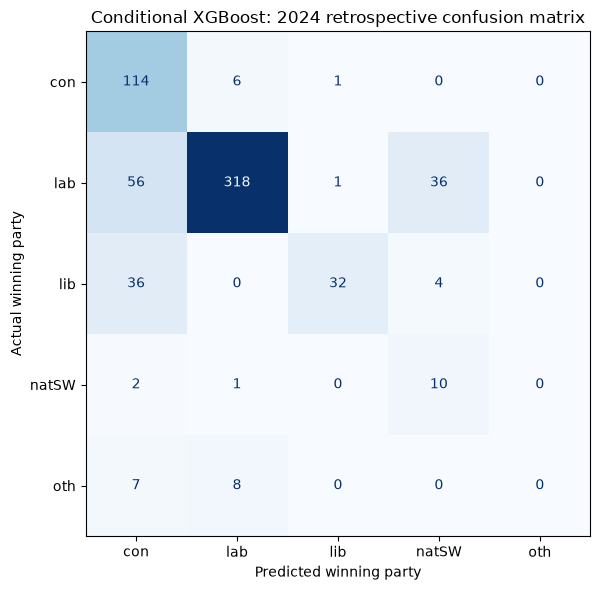

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

test_data = pd.read_csv(output_directory / "test.csv")
# Predict all seats; only unknown outcomes are excluded from accuracy scoring.
all_test_predictions = pd.Series(final_model.predict(test_data), index=test_data.index)
test_evaluation = test_data.dropna(subset=["winner"])
if test_evaluation.empty:
    raise ValueError("Test data has no known winners to evaluate.")
test_predictions = all_test_predictions.loc[test_evaluation.index].to_numpy()
test_accuracy = accuracy_score(test_evaluation["winner"], test_predictions)
print(f"Test accuracy ({model_type}): {test_accuracy:.2%}")
print(f"Evaluated {len(test_evaluation)} of {len(test_data)} test seats; "
      f"excluded {len(test_data) - len(test_evaluation)} rows with missing winners.")

party_labels = sorted(set(test_evaluation["winner"]) | set(test_predictions))
test_confusion_matrix = confusion_matrix(
    test_evaluation["winner"], test_predictions, labels=party_labels
)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(test_confusion_matrix, display_labels=party_labels).plot(
    ax=ax, cmap="Blues", values_format="d", colorbar=False
)
ax.set_title(f"{model_type}: 2024 retrospective confusion matrix")
ax.set_xlabel("Predicted winning party")
ax.set_ylabel("Actual winning party")
fig.tight_layout()

# Retain the final forecast outputs alongside the historical evaluation reports.
import json
prediction_export = test_data.copy()
prediction_export["predicted_winner"] = all_test_predictions
prediction_export.to_csv(output_directory / "test_predictions.csv", index=False)
pd.DataFrame(test_confusion_matrix, index=party_labels, columns=party_labels).to_csv(
    output_directory / "test_confusion_matrix.csv", index_label="actual_winner"
)
(output_directory / "test_metrics.json").write_text(json.dumps({
    "model": model_type,
    "accuracy": float(test_accuracy),
    "test_rows": len(test_data),
    "evaluated_rows": len(test_evaluation),
    "excluded_rows": len(test_data) - len(test_evaluation),
    "party_labels": party_labels,
}, indent=2) + "\n")
fig.savefig(output_directory / "test_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
